In [137]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [138]:
import pandas as pd
import numpy as np

In [139]:
path = "/content/drive/MyDrive/MICROPLASTIC_DATA_BASED_ON_LAT_LONG/SEA_MICRO.csv"

In [140]:
df = pd.read_csv(path)

# **EDA**(Exploratory Data Analysis)

In [141]:
df.head()

,Date,Latitude,Longitude,Pieces_KM2
0,1986-10-15,40.62,-70.07,0
1,1986-10-16,39.67,-69.43,0
2,1986-10-18,36.45,-64.88,3597
3,1986-10-19,35.48,-63.70,3597
4,1986-10-21,30.97,-60.68,17989


In [142]:
df.columns

Index(['Date', 'Latitude', 'Longitude', 'Pieces_KM2'], dtype='object')

In [143]:
df["Date"] = pd.to_datetime(df["Date"])

df["month"] = df["Date"].dt.month
df["year"] = df["Date"].dt.year
df["day"] = df["Date"].dt.day

In [144]:
df["season"] = df["month"].map({
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Summer", 4: "Summer", 5: "Summer",
    6: "Monsoon", 7: "Monsoon", 8: "Monsoon",
    9: "Monsoon", 10: "Post-Monsoon", 11: "Post-Monsoon"
})

In [145]:
df.columns

Index(['Date', 'Latitude', 'Longitude', 'Pieces_KM2', 'month', 'year', 'day',
       'season'],
      dtype='object')

In [146]:
import matplotlib.pyplot as plt
import seaborn as sns

# **1. Latitude vs Microplastic Density**

Microplastic density varies across different latitudes.

Some latitude regions show higher concentrations than others.

The points are widely spread, so there is no simple linear pattern.

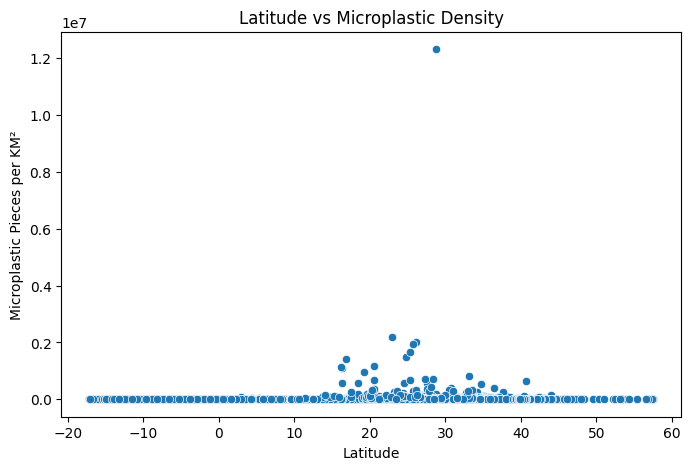

In [147]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Latitude",
    y="Pieces_KM2"
)

plt.title("Latitude vs Microplastic Density")
plt.xlabel("Latitude")
plt.ylabel("Microplastic Pieces per KM²")
plt.savefig("/content/Latitude vs Microplastic Density.png", dpi=300, bbox_inches="tight")
plt.show()

# **2. Longitude vs Microplastic Density**

Microplastic density also changes across different longitudes.

Some locations have much higher values than others.

This shows that microplastic pollution is not evenly distributed geographically.

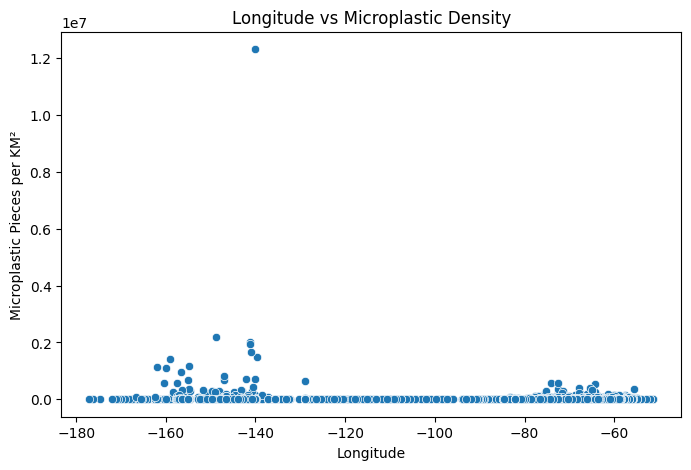

In [148]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Longitude",
    y="Pieces_KM2"
)

plt.title("Longitude vs Microplastic Density")
plt.xlabel("Longitude")
plt.ylabel("Microplastic Pieces per KM²")
plt.savefig("/content/Longitude vs Microplastic Density.png", dpi=300, bbox_inches="tight")
plt.show()

# **3. Monthly Average Microplastic Density**

The average density changes from month to month.

Some months have noticeably higher microplastic levels.

This suggests that microplastic concentration may vary over time.

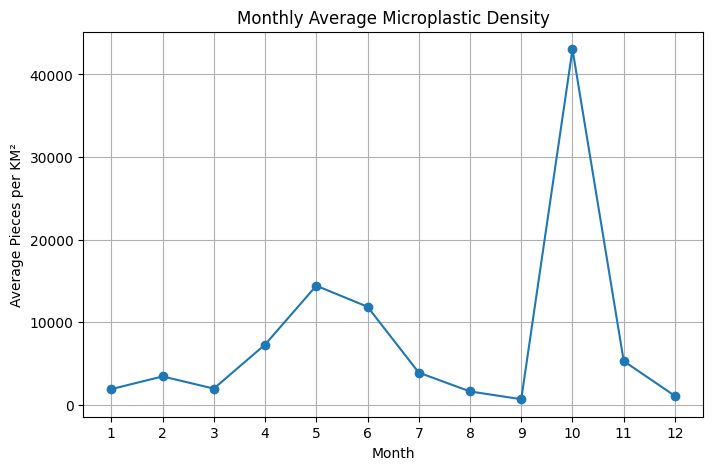

In [149]:
monthly_data = df.groupby("month")["Pieces_KM2"].mean()

plt.figure(figsize=(8, 5))

plt.plot(
    monthly_data.index,
    monthly_data.values,
    marker="o"
)

plt.title("Monthly Average Microplastic Density")
plt.xlabel("Month")
plt.ylabel("Average Pieces per KM²")
plt.xticks(range(1, 13))
plt.grid(True)
plt.savefig("/content/ Monthly Average Microplastic Density.png", dpi=300, bbox_inches="tight")
plt.show()

# **4. Microplastic Density Distribution**

Most observations are concentrated in a lower density range.

A few observations have much higher values.

This indicates that the dataset contains some high-density locations.

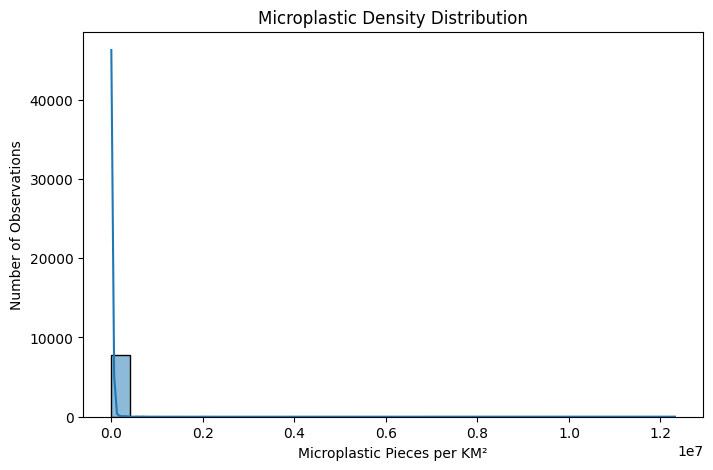

In [150]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Pieces_KM2"],
    bins=30,
    kde=True
)

plt.title("Microplastic Density Distribution")
plt.xlabel("Microplastic Pieces per KM²")
plt.ylabel("Number of Observations")
plt.savefig("/content/Microplastic Density Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [151]:
df.isnull().sum()

,0
Date,0
Latitude,0
Longitude,0
Pieces_KM2,0
month,0
year,0
day,0
season,0


In [152]:
df.duplicated().sum()

np.int64(0)

In [153]:
df.shape

(7755, 8)

In [171]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7755 entries, 0 to 7754
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        7755 non-null   datetime64[ns]
 1   Latitude    7755 non-null   float64       
 2   Longitude   7755 non-null   float64       
 3   Pieces_KM2  7755 non-null   int64         
 4   month       7755 non-null   int32         
 5   year        7755 non-null   int32         
 6   day         7755 non-null   int32         
 7   season      7755 non-null   object        
dtypes: datetime64[ns](1), float64(2), int32(3), int64(1), object(1)
memory usage: 393.9+ KB
